In [1]:
!pip install SciencePlots
!pip install latex
!sudo apt-get update
!sudo apt-get install dvipng texlive-latex-extra texlive-fonts-recommended cm-super
import matplotlib.ticker as ticker
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use('science')
!pip install pamda

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for latex: filename=latex-0.7.0-py3-none-any.whl size=7589 sha256=24334f464e174628d21f4e67f541edef16894edfe2ca3a02c8e0828d7b558b96
  Stored in directory: /root/.cache/pip/wheels/4c/6e/66/29e29480ca5a0c0b2c628bec4e37c21f3eafcd53b0282b48e2
  Created wheel for data: filename=data-0.4-py3-none-any.whl size=7226 sha256=b05a862d64dafa6034f918074d3df56b050fd8c3afb3034a7481235e485562f2
  Stored in directory: /root/.cache/pip/wheels/0e/90/87/0e55006f5c69af278687927041e334cfb928ab0a7ad9b0c1a3
  Created wheel for shutilwhich: filename=shutilwhich-1.1.0-py3-none-any.whl size=2766 sha256=fefe36d189b453a0493e4e5a1cabe43bdc5edfbb7e6520cc75ea13d89f91bb59
  Stored in directory: /root/.cache/pip/wheels/6d/11/16/61438ffcedd8e5438380547db00e51b4b00cf7fc107714183f
  Created wheel for tempdir: filename=tempdir-0.7.1-py3-none-any.w

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm
from pamda import pamda
import math
from collections import defaultdict
from scipy.optimize import curve_fit
import numpy as np

In [3]:
algorithms = {
    "bmssp_constant_degree_solve_time_ms": {"label": "BMSSP (Constant Degree)", "cmap": cm.Blues},
    "sc_dijkstra_constant_degree_time_ms": {"label": "SC Dijkstra (Constant Degree)", "cmap": cm.Reds},
    "bmssp_solve_time_ms": {"label": "BMSSP", "cmap": cm.cividis},
    "sc_dijkstra_time_ms": {"label": "SC Dijkstra", "cmap": cm.viridis},
    "pure_python_sc_dijkstra_time_ms": {"label": "Pure Python SC Dijkstra", "cmap": cm.Oranges},
    "pure_python_heapdict_sc_dijkstra_time_ms": {"label": "Pure Python SC Dijkstra (HeapDict)", "cmap": cm.RdBu},
    "vanilla_dijkstra_time_ms": {"label": "Vanilla Dijkstra", "cmap": cm.Greens},
    "nx_dijkstra_time_ms": {"label": "NetworkX Dijkstra", "cmap": cm.Purples},
    "ig_dijkstra_time_ms": {"label": "iGraph Dijkstra", "cmap": cm.Greys}
}

algorithms_no_vanilla = {k:v for k,v in algorithms.items() if k != "vanilla_dijkstra_time_ms"}
algorithms_no_constant_degree = {k:v for k, v in algorithms.items() if 'constant_degree' not in k}
algorithms_faster = {k:v for k, v in algorithms.items() if 'bmssp_constant_degree_solve_time_ms' not in k}

ITERATIONS_PER_CASE = 2

In [4]:
def make_aggregated_graph(data, title, scale="linear", algorithms=algorithms):
    # Structure: { algorithm: { nodes: [ (time, stdev) ] } }
    aggregated_data = {alg: defaultdict(list) for alg in algorithms}

    for row in data:
        try:
            nodes = int(row["graph_nodes"]) + int(row.get("graph_edges", 0))

            for alg in algorithms:
                time_val = float(row.get(alg, "nan"))
                stdev_val = float(row.get(alg.replace("_time_ms", "_stdev"), "nan"))

                if math.isnan(time_val) or math.isnan(stdev_val):
                    continue

                aggregated_data[alg][nodes].append((time_val, stdev_val))

        except Exception:
            continue  # Skip rows with invalid data

    # Plotting
    plt.figure(figsize=(14, 9))

    for alg_key, node_dict in aggregated_data.items():
        if not any(node_dict.values()):
            continue  # Skip algorithms with no data

        nodes = sorted(node_dict.keys())
        avg_times = []
        combined_stdevs = []

        for n in nodes:
            points = node_dict[n]
            if not points:
                continue

            times = [p[0] for p in points]
            stdevs = [p[1] for p in points]
            k = len(points)

            mean_time = sum(times) / k
            avg_times.append(mean_time)

            variance_components = [
                ITERATIONS_PER_CASE * (std**2 + (time - mean_time)**2)
                for time, std in zip(times, stdevs)
            ]
            combined_variance = sum(variance_components) / (k ** 2)
            combined_stdev = math.sqrt(combined_variance / ITERATIONS_PER_CASE)
            combined_stdevs.append(combined_stdev)

        label = algorithms[alg_key]["label"]
        color = algorithms[alg_key]["cmap"](0.8)  # Mid-dark shade

        # Plot line
        plt.plot(nodes, avg_times, label=label, color=color, linestyle='-', marker='o', linewidth=1.8)

        # Plot error band
        lower = [t - s for t, s in zip(avg_times, combined_stdevs)]
        upper = [t + s for t, s in zip(avg_times, combined_stdevs)]
        plt.fill_between(nodes, lower, upper, color=color, alpha=0.15)

    # Final plot formatting
    plt.title(title)
    plt.xlabel("Number of Nodes and Edges")
    plt.ylabel("Time (ms)")
    if scale == "log":
        plt.xscale("log")
        plt.yscale("log")
    elif scale == "linear":
        pass
    else:
        raise ValueError("Scale must be 'linear' or 'log'")
    plt.grid(True)
    plt.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

In [5]:
def make_graph(data, title, scale="linear", algorithms=algorithms):
    # Structure: { algorithm: { case_name: [ (nodes, time, stdev) ] } }
    grouped_data = {alg: {} for alg in algorithms}

    for row in data:
        try:
            case = row["case_name"]
            # nodes = int(row["graph_nodes"]) # Number of nodes
            nodes = int(row["graph_nodes"])+int(row.get("graph_edges", 0))  # Total nodes + edges for complexity
            for alg in algorithms:
                time = float(row.get(alg, "nan"))
                stdev = float(row.get(alg.replace("_time_ms", "_stdev"), "nan"))
                if time != float("nan") and stdev != float("nan"):
                    if case not in grouped_data[alg]:
                        grouped_data[alg][case] = []
                    grouped_data[alg][case].append((nodes, time, stdev))
        except:
            continue  # Skip rows with invalid data

    # Plotting
    plt.figure(figsize=(14, 9))

    for alg_key, case_dict in grouped_data.items():
        cases = list(case_dict.items())
        num_cases = len(cases)

        for i, (case_name, points) in enumerate(cases):
            if not points:
                continue
            # Sort by number of nodes
            points.sort(key=lambda x: x[0])
            nodes = [p[0] for p in points]
            times = [p[1] for p in points]
            stdevs = [p[2] for p in points]

            label = f"{algorithms[alg_key]['label']} ({case_name})"

            # Use a colormap to assign a different shade for each case
            cmap = algorithms[alg_key]["cmap"]
            color = cmap(0.4 + 0.6 * i / max(1, num_cases - 1))  # Shades from 0.4 to 1.0

            # Plot line
            plt.plot(nodes, times, label=label, color=color, linestyle='-', marker='o', linewidth=1.5)

            # # Plot error band
            lower = [t - s for t, s in zip(times, stdevs)]
            upper = [t + s for t, s in zip(times, stdevs)]
            plt.fill_between(nodes, lower, upper, color=color, alpha=0.1)

    # Final plot formatting
    plt.title(title)
    plt.xlabel("Number of Nodes and Edges")
    plt.ylabel("Time (ms)")

    if scale == "log":
        plt.xscale("log")
        plt.yscale("log")
    elif scale == "linear":
        pass
    else:
        raise ValueError("Scale must be 'linear' or 'log'")

    plt.grid(True)
    plt.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

In [6]:
def make_relative_performance_graph(data, title, baseline_alg, scale="linear", algorithms=algorithms):

    if baseline_alg not in algorithms:
        raise ValueError(f"Invalid baseline algorithm: {baseline_alg}")

    # Structure: { algorithm: { nodes: [ (time, stdev) ] } }
    aggregated_data = {alg: defaultdict(list) for alg in algorithms}

    for row in data:
        try:
            nodes = int(row["graph_nodes"]) + int(row.get("graph_edges", 0))

            for alg in algorithms:
                time_val = float(row.get(alg, "nan"))
                stdev_val = float(row.get(alg.replace("_time_ms", "_stdev"), "nan"))

                if math.isnan(time_val) or math.isnan(stdev_val):
                    continue

                aggregated_data[alg][nodes].append((time_val, stdev_val))

        except Exception:
            continue  # Skip invalid rows

    # Compute mean and stdev per node count
    mean_data = {}
    for alg, node_dict in aggregated_data.items():
        mean_data[alg] = {}
        for n, points in node_dict.items():
            times = [p[0] for p in points]
            stdevs = [p[1] for p in points]
            k = len(times)
            if k == 0:
                continue
            mean_time = sum(times) / k
            # Combined variance
            variance_components = [
                ITERATIONS_PER_CASE * (std**2 + (time - mean_time)**2)
                for time, std in zip(times, stdevs)
            ]
            combined_variance = sum(variance_components) / (k ** 2)
            combined_stdev = math.sqrt(combined_variance / ITERATIONS_PER_CASE)
            mean_data[alg][n] = (mean_time, combined_stdev)

    # Prepare the plot
    plt.figure(figsize=(14, 9))
    nodes = sorted(mean_data[baseline_alg].keys())

    for alg, props in algorithms.items():
        if alg == baseline_alg:
            continue

        x_vals = []
        multipliers = []
        multiplier_stdevs = []

        for n in nodes:
            if n not in mean_data[alg] or n not in mean_data[baseline_alg]:
                continue

            t_other, s_other = mean_data[alg][n]
            t_base, s_base = mean_data[baseline_alg][n]

            if t_base == 0:
                continue  # Avoid division by zero

            multiplier = t_other / t_base

            # Error propagation formula for ratio:
            # σ_r = r * sqrt((σ_a / a)^2 + (σ_b / b)^2)
            ratio_stdev = multiplier * math.sqrt(
                (s_other / t_other) ** 2 + (s_base / t_base) ** 2
            )

            x_vals.append(n)
            multipliers.append(multiplier)
            multiplier_stdevs.append(ratio_stdev)

        if not x_vals:
            continue

        color = props["cmap"](0.8)
        label = f"{props['label']} vs {algorithms[baseline_alg]['label']}"

        plt.plot(x_vals, multipliers, label=label, color=color, marker='o', linewidth=1.8)
        lower = [m - s for m, s in zip(multipliers, multiplier_stdevs)]
        upper = [m + s for m, s in zip(multipliers, multiplier_stdevs)]
        plt.fill_between(x_vals, lower, upper, color=color, alpha=0.15)

    plt.axhline(1.0, color='black', linestyle='--', linewidth=1, label="Baseline (×1)")
    plt.title(title)
    plt.xlabel("Number of Nodes and Edges")
    plt.ylabel(f"Runtime Multiplier vs {algorithms[baseline_alg]['label']}")
    if scale == "log":
        plt.xscale("log")
    elif scale == "linear":
        pass
    else:
        raise ValueError("Scale must be 'linear' or 'log'")
    plt.yscale("linear")
    plt.grid(True)
    plt.legend(fontsize='small', loc='upper left', bbox_to_anchor=(1.02, 1))
    plt.tight_layout()
    plt.show()

In [7]:
def power_law(x, a, b):
    return a * x ** b

def fit_curve(x, y):
    (a, b), _ = curve_fit(power_law, x, y, maxfev=10000)
    return (a, b)

def find_crossover(a1, b1, a2, b2):
    if b1 == b2:
        return None  # No crossover if slopes are equal
    out = (a2 / a1) ** (1 / (b1 - b2))
    return out if out > 1 else None

def plot_with_crossover(x, y1, y2, a1, b1, a2, b2, x_cross, title, algo_1_name, algo_2_name,scale="linear"):
    x_max = max(max(x), x_cross * 1.2 if x_cross else max(x) * 2)
    x_fit = np.linspace(min(x), x_max)

    y1_fit = power_law(x_fit, a1, b1)
    y2_fit = power_law(x_fit, a2, b2)

    plt.figure(figsize=(12, 8))
    plt.scatter(x, y1, label=algo_1_name, color="blue")
    plt.scatter(x, y2, label=algo_2_name, color="red")
    plt.plot(x_fit, y1_fit, label=f"{algo_1_name} Fit: {a1:.2e} x{b1:.2f}", color="blue", linestyle="--")
    plt.plot(x_fit, y2_fit, label=f"{algo_2_name} Fit: {a2:.2e} x{b2:.2f}", color="red", linestyle="--")

    if x_cross:
        y_cross = power_law(x_cross, a1, b1)
        plt.axvline(x_cross, color="green", linestyle=":", label=f"Crossover at {x_cross:.2e} (nodes + edges)")
        plt.scatter([x_cross], [y_cross], color="green", zorder=5)

    plt.xlabel("Nodes + Edges")
    plt.ylabel("Runtime (ms)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if scale == "log":
        plt.xscale("log")
        plt.yscale("log")
    elif scale == "linear":
        pass
    else:
        raise ValueError("Scale must be 'linear' or 'log'")
    plt.tight_layout()
    plt.show()


In [8]:
data = pamda.read_csv(filename="benchmark_time_tests.csv")
gridscale_data = pamda.read_csv(filename="benchmark_time_tests.csv")

In [9]:
import pandas as pd
a = pd.read_csv("benchmark_time_tests.csv")
a.columns

Index(['graph_name', 'case_name', 'graph_nodes', 'graph_edges',
       'constant_degree_graph_nodes', 'constant_degree_graph_edges',
       'origin_node', 'iterations', 'bmssp_constant_degree_solve_time_ms',
       'bmssp_constant_degree_solve_stdev',
       'pure_python_sc_dijkstra_constant_degree_time_ms',
       'pure_python_sc_dijkstra_constant_degree_stdev', 'bmssp_solve_time_ms',
       'bmssp_solve_stdev', 'vanilla_dijkstra_time_ms',
       'vanilla_dijkstra_stdev', 'sc_dijkstra_time_ms', 'sc_dijkstra_stdev',
       'pure_python_sc_dijkstra_time_ms', 'pure_python_sc_dijkstra_stdev',
       'nx_dijkstra_time_ms', 'nx_dijkstra_stdev', 'ig_dijkstra_time_ms',
       'ig_dijkstra_stdev', 'raw'],
      dtype='object')

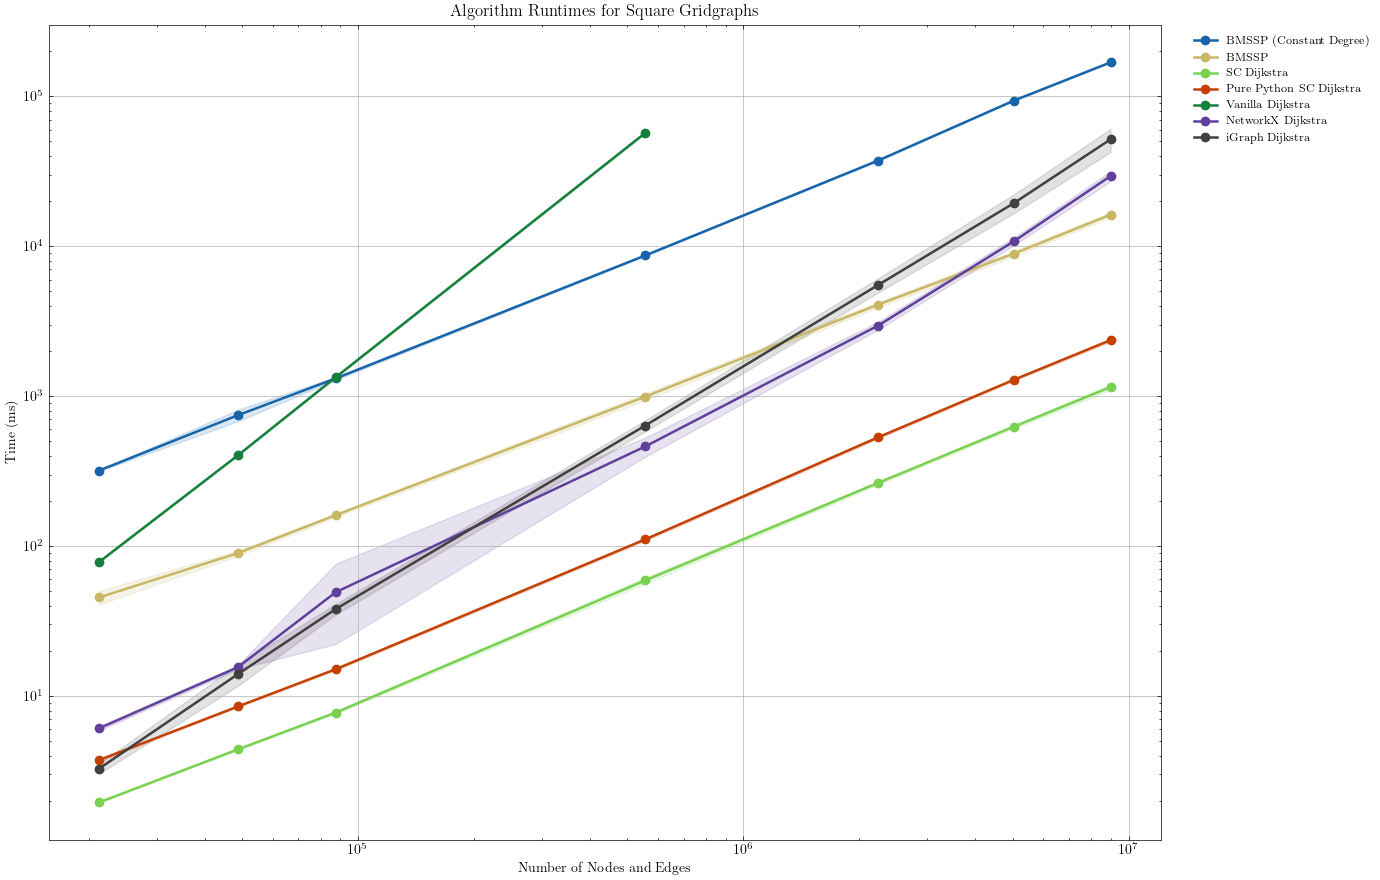

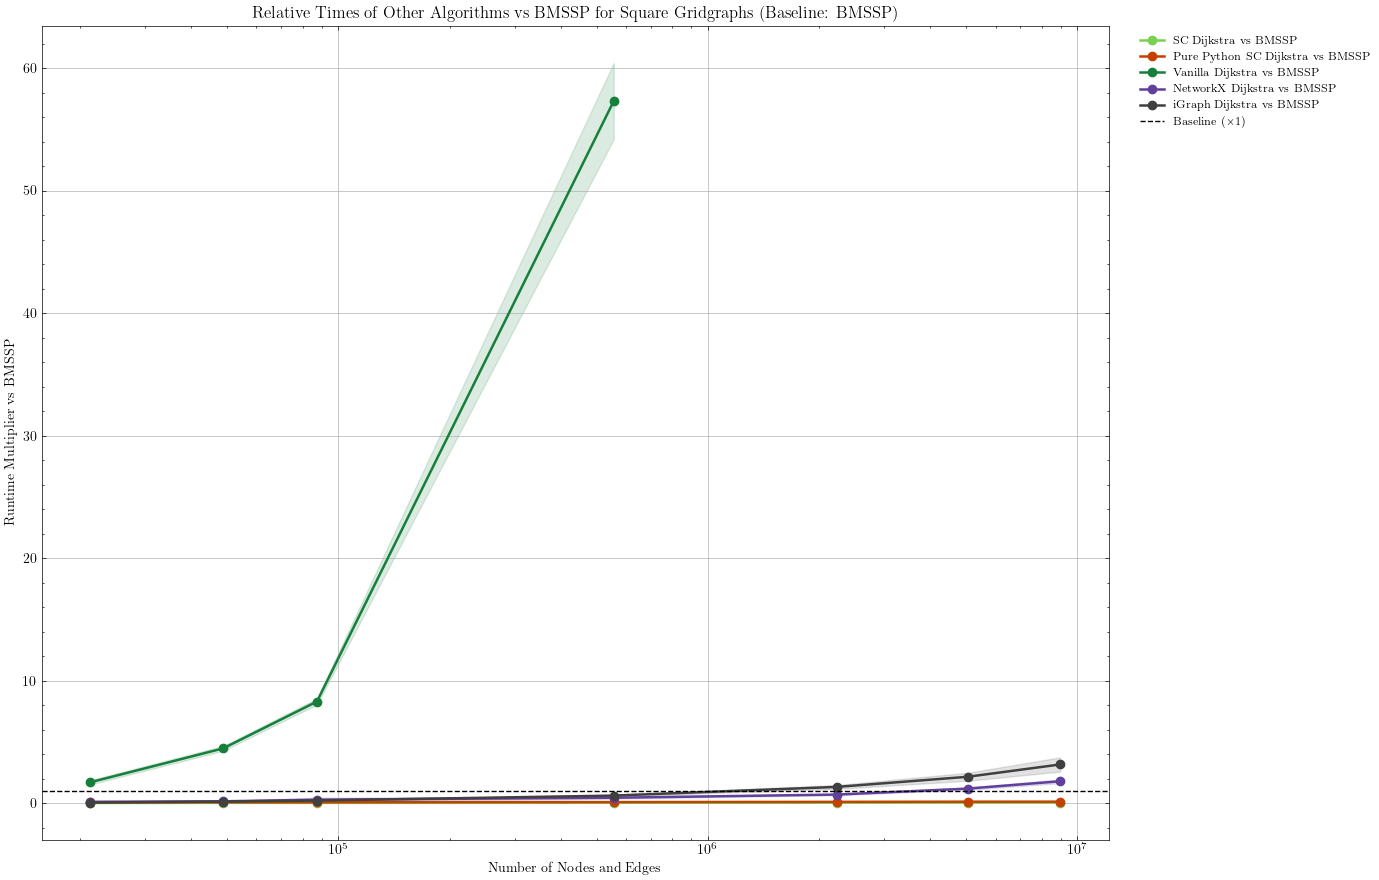

In [10]:
square_grid_data = [i for i in data if 'Square' in i['graph_name']]

make_aggregated_graph(
    square_grid_data,
    "Algorithm Runtimes for Square Gridgraphs",
    scale="log",
)
make_relative_performance_graph(
    square_grid_data,
    "Relative Times of Other Algorithms vs BMSSP for Square Gridgraphs (Baseline: BMSSP)",
    baseline_alg="bmssp_solve_time_ms",
    scale="log",
    algorithms=algorithms_faster
)

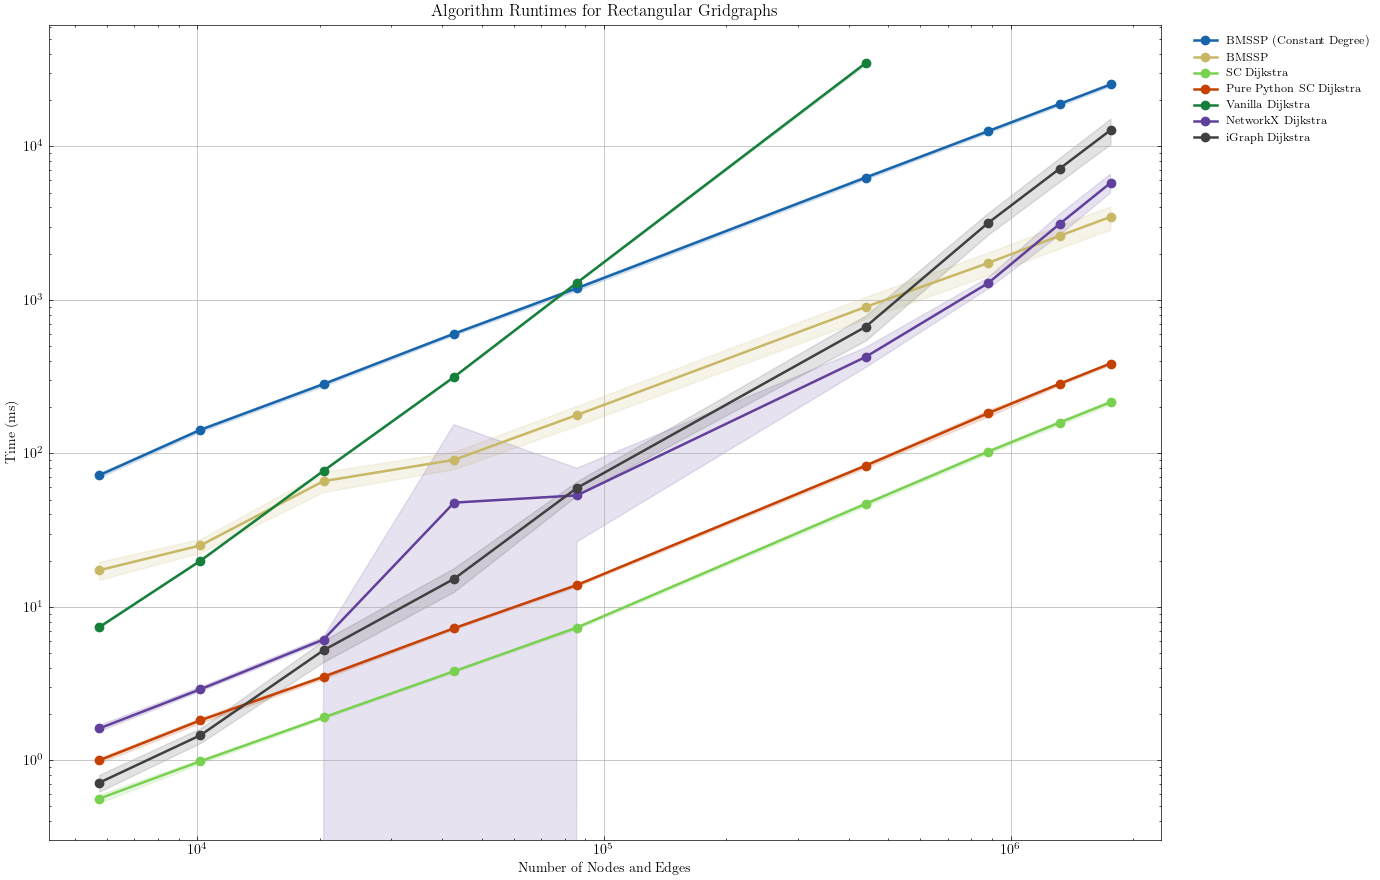

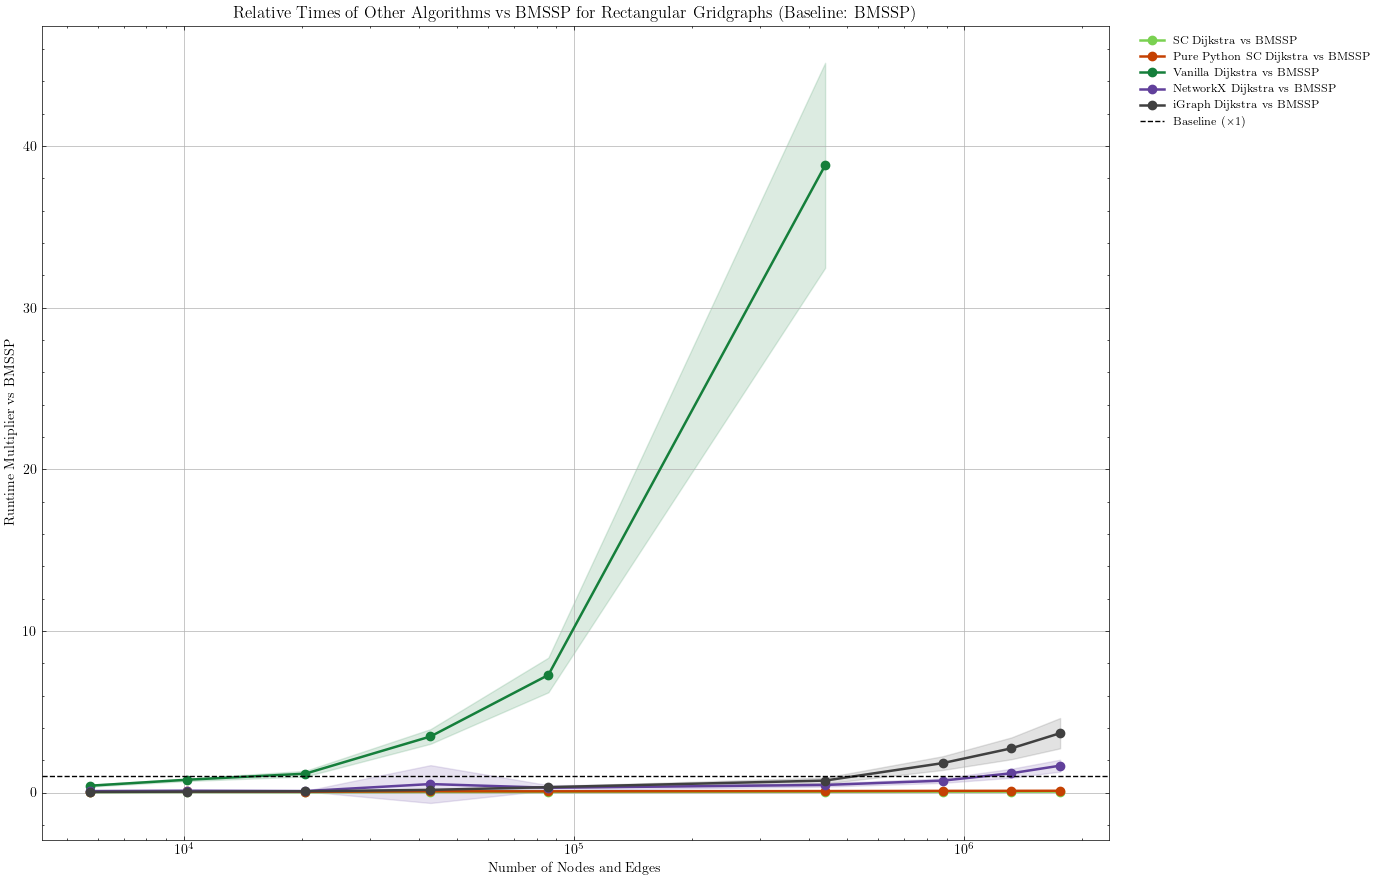

In [11]:
rectangular_grid_data = [i for i in data if 'Rectangular' in i['graph_name']]
make_aggregated_graph(rectangular_grid_data, "Algorithm Runtimes for Rectangular Gridgraphs", scale="log")
make_relative_performance_graph(rectangular_grid_data, "Relative Times of Other Algorithms vs BMSSP for Rectangular Gridgraphs (Baseline: BMSSP)", baseline_alg="bmssp_solve_time_ms", scale="log", algorithms=algorithms_faster)

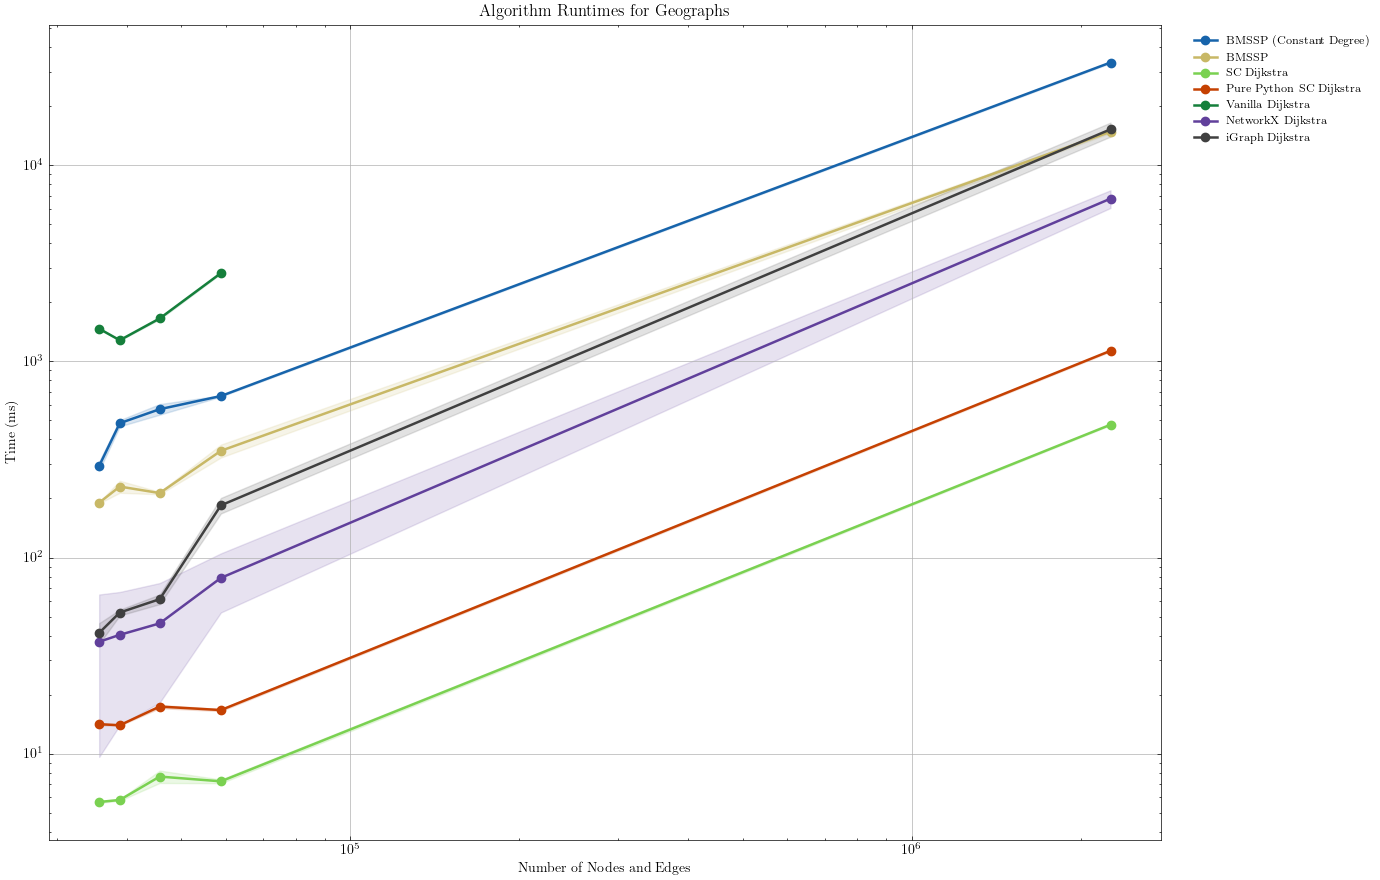

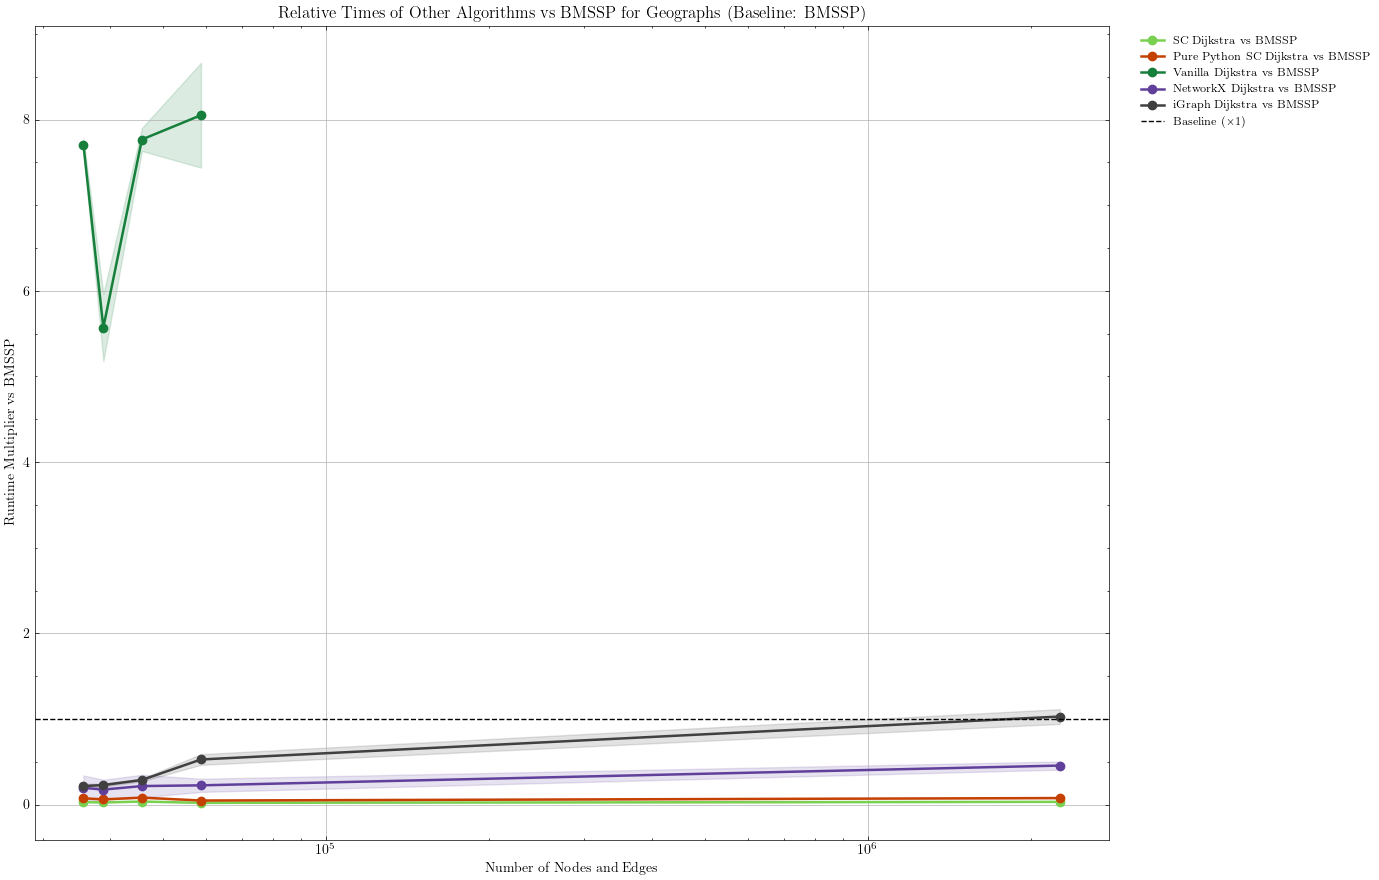

In [12]:
geograph_data = [i for i in data if 'Geograph' in i['graph_name']]

make_aggregated_graph(geograph_data, "Algorithm Runtimes for Geographs", scale="log")

# Omit the Vanilla Dijkstra for more clarity
no_vd = {k:v for k, v in algorithms.items() if k != "vanilla_dijkstra_time_ms"}
make_relative_performance_graph(geograph_data, "Relative Times of Other Algorithms vs BMSSP for Geographs (Baseline: BMSSP)", baseline_alg="bmssp_solve_time_ms", scale="log", algorithms=algorithms_faster)

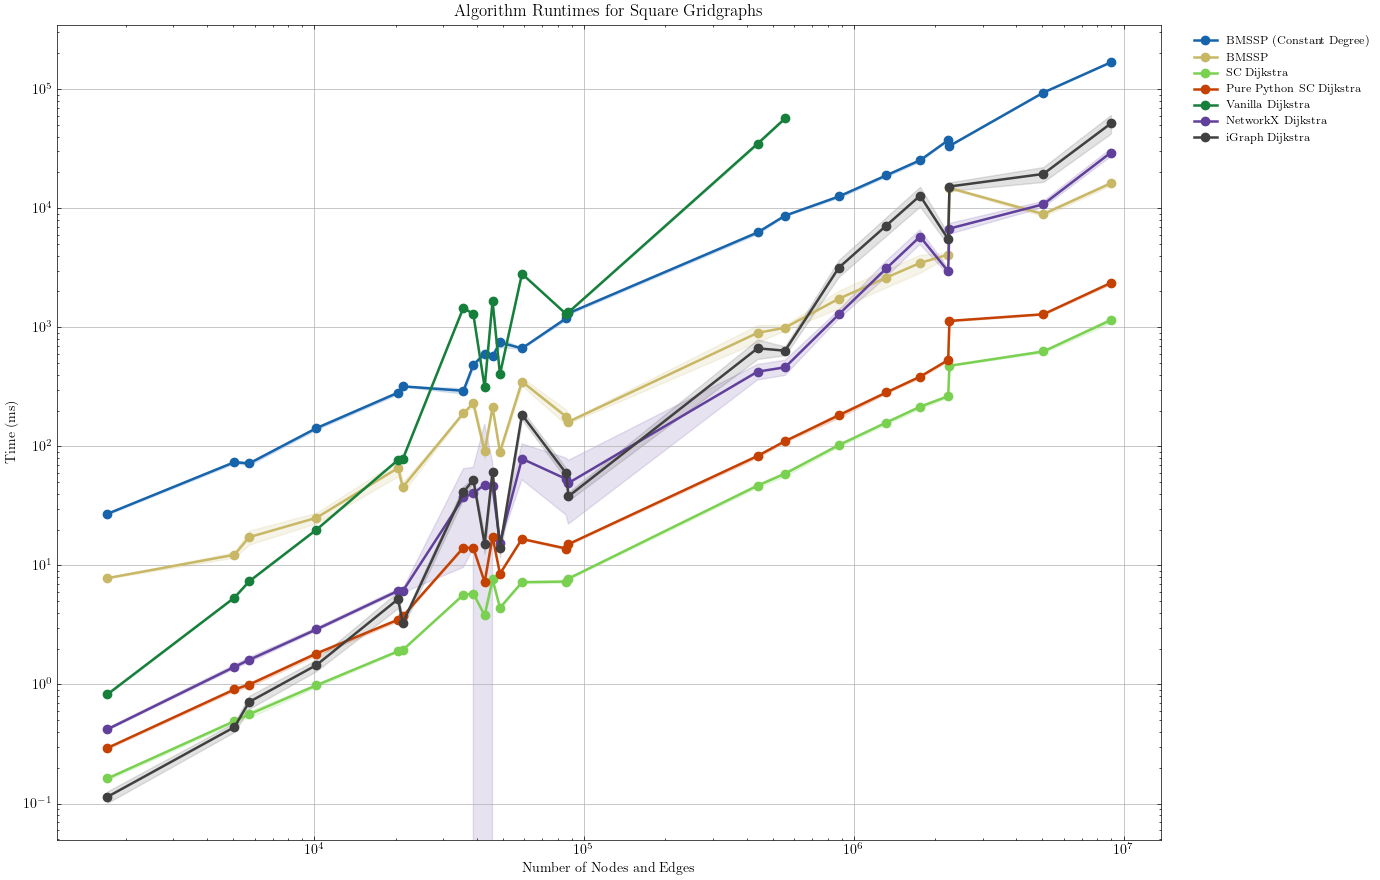

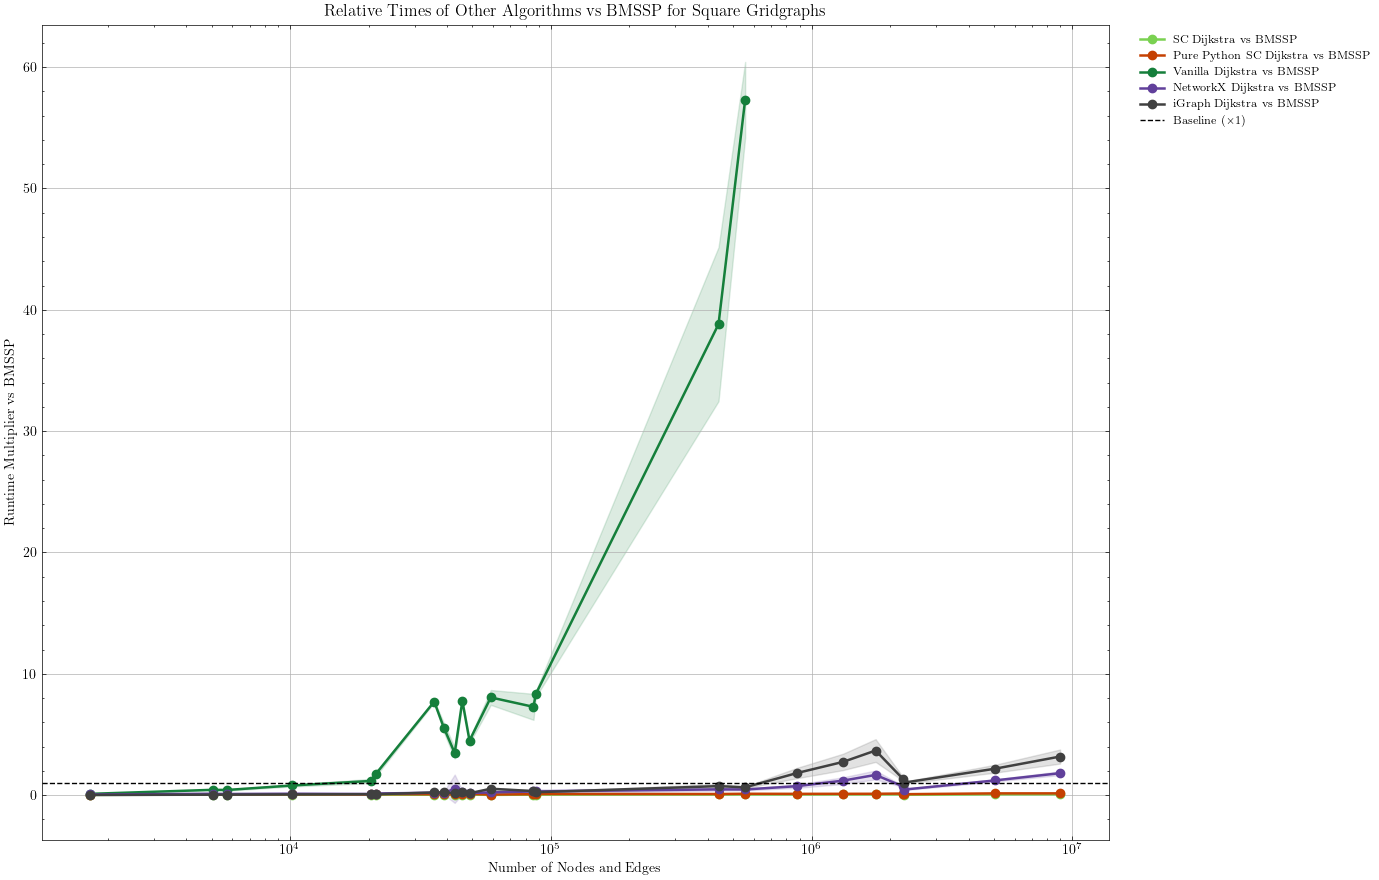

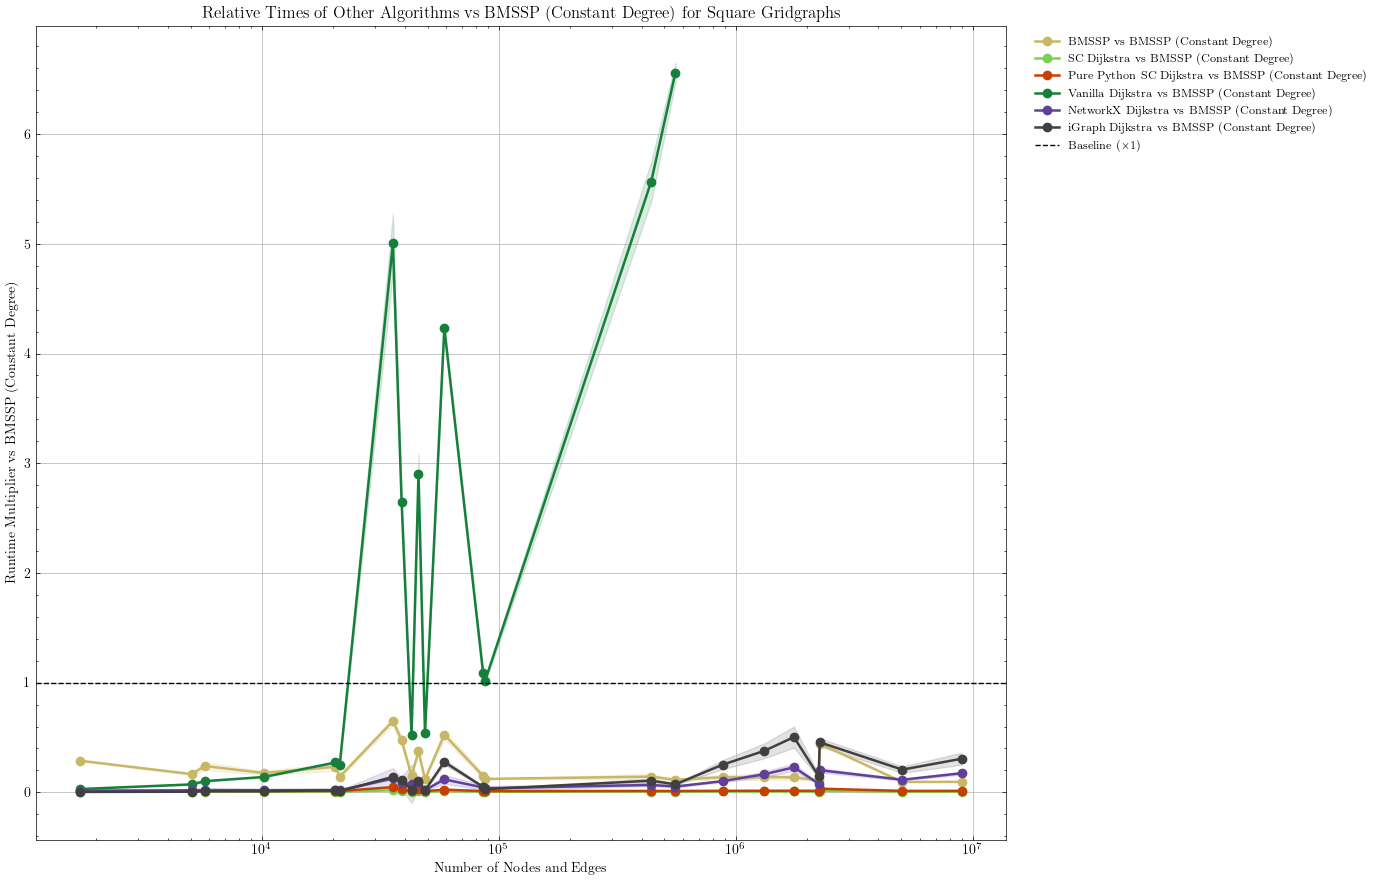

In [13]:
make_aggregated_graph(gridscale_data, "Algorithm Runtimes for Square Gridgraphs", scale="log")
make_relative_performance_graph(gridscale_data, "Relative Times of Other Algorithms vs BMSSP for Square Gridgraphs", baseline_alg="bmssp_solve_time_ms", scale="log", algorithms=algorithms_no_constant_degree)
make_relative_performance_graph(gridscale_data, "Relative Times of Other Algorithms vs BMSSP (Constant Degree) for Square Gridgraphs", baseline_alg="bmssp_constant_degree_solve_time_ms", scale="log")

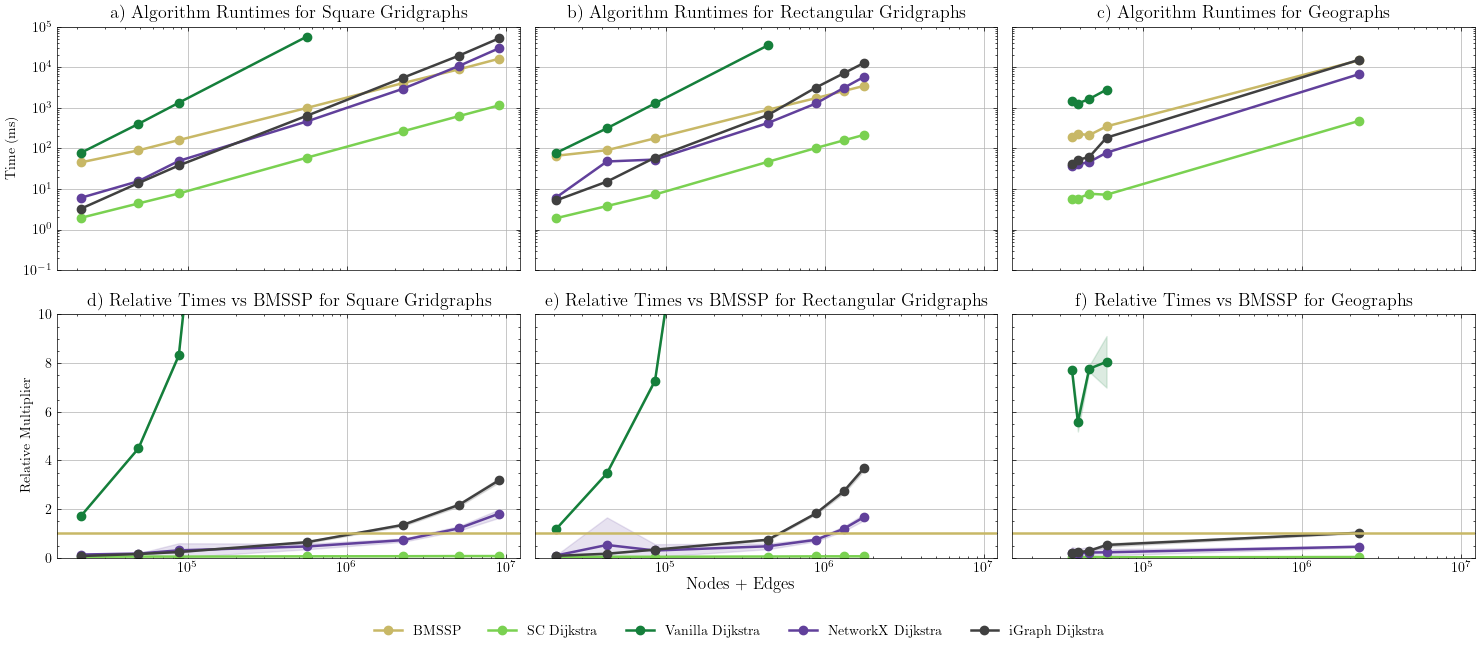

In [14]:
import math
import matplotlib.pyplot as plt
from collections import defaultdict

# ------------------------------------------
# Filtered algorithm sets (no Constant Degree / Pure Python)
# ------------------------------------------
def is_allowed_alg(props):
    lbl = props["label"]
    return ("Constant Degree" not in lbl) and ("Pure Python" not in lbl)

algorithms_filtered = {k: v for k, v in algorithms.items() if is_allowed_alg(v)}
algorithms_faster_filtered = {
    k: v for k, v in algorithms_faster.items() if k in algorithms_filtered
}

baseline_alg = "bmssp_solve_time_ms"
assert baseline_alg in algorithms_filtered

# ------------------------------------------
# Datasets
# ------------------------------------------
square_grid_data = [i for i in data if "Square GridGraph" in i["graph_name"]]
rectangular_grid_data = [i for i in data if "Rectangular GridGraph" in i["graph_name"]]
geograph_data = [i for i in data if "Geograph" in i["graph_name"]]

datasets = [
    ("Square Gridgraphs", square_grid_data),
    ("Rectangular Gridgraphs", rectangular_grid_data),
    ("Geographs", geograph_data),
]

subplot_labels = [("a)", "b)", "c)"), ("d)", "e)", "f)")]

global_legend_labels = {
    alg: props["label"] for alg, props in algorithms_filtered.items()
}

# ------------------------------------------
# Figure setup (shared x-axis)
# ------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)

for col, (title_prefix, dataset) in enumerate(datasets):

    # =========================
    # ROW 1: Absolute runtimes
    # =========================
    ax = axes[0, col]
    ax.set_title(f"{subplot_labels[0][col]} Algorithm Runtimes for {title_prefix}",
                 fontsize=13)

    aggregated = {alg: defaultdict(list) for alg in algorithms_filtered}

    for row in dataset:
        try:
            nodes = int(row["graph_nodes"]) + int(row["graph_edges"])
            for alg in algorithms_filtered:
                t = float(row.get(alg, "nan"))
                s = float(row.get(alg.replace("_time_ms", "_stdev"), "nan"))
                if math.isnan(t) or math.isnan(s):
                    continue
                aggregated[alg][nodes].append((t, s))
        except Exception:
            continue

    meanvals = {}
    for alg, nodemap in aggregated.items():
        meanvals[alg] = {}
        for n, pts in nodemap.items():
            times = [p[0] for p in pts]
            stdevs = [p[1] for p in pts]
            if not times:
                continue
            k = len(times)
            mt = sum(times) / k
            ms = sum(stdevs) / k
            meanvals[alg][n] = (mt, ms)

    for alg, node_map in meanvals.items():
        xs = sorted(node_map.keys())
        if not xs:
            continue
        ys = [node_map[n][0] for n in xs]
        es = [node_map[n][1] for n in xs]

        color = algorithms_filtered[alg]["cmap"](0.8)
        label = global_legend_labels[alg]

        ax.plot(xs, ys, color=color, marker='o', linewidth=1.8, label=label)
        # ax.fill_between(xs,
        #                 [y - e for y, e in zip(ys, es)],
        #                 [y + e for y, e in zip(ys, es)],
        #                 color=color, alpha=0.15)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1e-1, 1e5)
    ax.grid(True)

    if col > 0:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
    else:
        ax.set_ylabel("Time (ms)")

    # =========================
    # ROW 2: Relative multipliers
    # =========================
    ax2 = axes[1, col]
    ax2.set_title(f"{subplot_labels[1][col]} Relative Times vs BMSSP for {title_prefix}",
                  fontsize=13)

    reldata = {alg: defaultdict(list) for alg in algorithms_faster_filtered}

    for row in dataset:
        try:
            nodes = int(row["graph_nodes"]) + int(row["graph_edges"])
            for alg in algorithms_faster_filtered:
                t = float(row.get(alg, "nan"))
                s = float(row.get(alg.replace("_time_ms", "_stdev"), "nan"))
                if math.isnan(t) or math.isnan(s):
                    continue
                reldata[alg][nodes].append((t, s))
        except Exception:
            continue

    relmeans = {}
    for alg, nodemap in reldata.items():
        relmeans[alg] = {}
        for n, pts in nodemap.items():
            times = [p[0] for p in pts]
            stdevs = [p[1] for p in pts]
            if not times:
                continue
            k = len(times)
            mt = sum(times) / k
            ms = sum(stdevs) / k
            relmeans[alg][n] = (mt, ms)

    base_nodes = sorted(relmeans.get(baseline_alg, {}).keys())

    for alg in algorithms_faster_filtered:
        if alg == baseline_alg:
            continue

        xs, ys, es = [], [], []

        for n in base_nodes:
            if n not in relmeans[alg] or n not in relmeans[baseline_alg]:
                continue
            t_a, s_a = relmeans[alg][n]
            t_b, s_b = relmeans[baseline_alg][n]
            if t_b == 0:
                continue

            ratio = t_a / t_b
            ratio_std = ratio * math.sqrt(
                (s_a / t_a) ** 2 + (s_b / t_b) ** 2
            )

            xs.append(n)
            ys.append(ratio)
            es.append(ratio_std)

        if not xs:
            continue

        color = algorithms_filtered[alg]["cmap"](0.8)
        label = global_legend_labels[alg] + " vs BMSSP"

        ax2.plot(xs, ys, marker='o', linewidth=1.8, color=algorithms_filtered[alg]["cmap"](0.8), label=label)
        ax2.fill_between(xs,
                         [y - e for y, e in zip(ys, es)],
                         [y + e for y, e in zip(ys, es)],
                         color=color, alpha=0.15)

    ax2.axhline(1.0, color=algorithms_filtered['bmssp_solve_time_ms']["cmap"](0.8), linestyle="-", linewidth=1.8)
    ax2.set_xscale("log")
    ax2.set_ylim(0, 10)
    ax2.grid(True)

    if col > 0:
        ax2.set_ylabel("")
        ax2.tick_params(labelleft=False)
    else:
        ax2.set_ylabel("Relative Multiplier")

# ------------------------------------------
# Layout: reserve extra bottom space
# ------------------------------------------
# Tight layout, leaving room at the bottom for legend + shared x-label
plt.tight_layout(rect=[0, 0., 1, 1])

# Shared x-axis label a bit above the bottom
fig.text(0.5, 0., "Nodes + Edges", ha="center", fontsize=12)

# Global legend between plots and x-label
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.1),
           ncol=6, fontsize=10)

plt.savefig("algorithm_runtimes.pdf", bbox_inches="tight")
plt.show()


In [15]:
algorithms_filtered

{'bmssp_solve_time_ms': {'label': 'BMSSP',
  'cmap': <matplotlib.colors.ListedColormap at 0x7b9c321438c0>},
 'sc_dijkstra_time_ms': {'label': 'SC Dijkstra',
  'cmap': <matplotlib.colors.ListedColormap at 0x7b9c321437d0>},
 'vanilla_dijkstra_time_ms': {'label': 'Vanilla Dijkstra',
  'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7b9c32143b90>},
 'nx_dijkstra_time_ms': {'label': 'NetworkX Dijkstra',
  'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7b9c32143e60>},
 'ig_dijkstra_time_ms': {'label': 'iGraph Dijkstra',
  'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7b9c32143bc0>}}

In [16]:
algorithms_faster_filtered

{'bmssp_solve_time_ms': {'label': 'BMSSP',
  'cmap': <matplotlib.colors.ListedColormap at 0x7b9c321438c0>},
 'sc_dijkstra_time_ms': {'label': 'SC Dijkstra',
  'cmap': <matplotlib.colors.ListedColormap at 0x7b9c321437d0>},
 'vanilla_dijkstra_time_ms': {'label': 'Vanilla Dijkstra',
  'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7b9c32143b90>},
 'nx_dijkstra_time_ms': {'label': 'NetworkX Dijkstra',
  'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7b9c32143e60>},
 'ig_dijkstra_time_ms': {'label': 'iGraph Dijkstra',
  'cmap': <matplotlib.colors.LinearSegmentedColormap at 0x7b9c32143bc0>}}

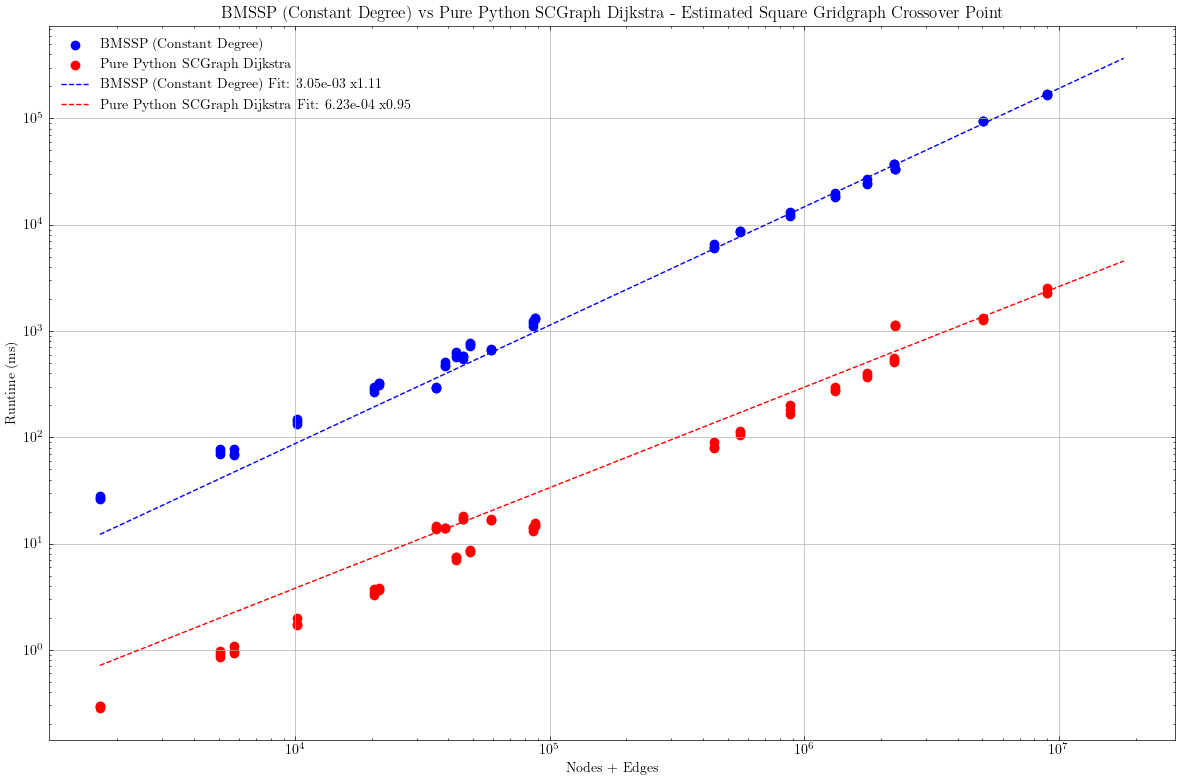

In [17]:
x_vals = [i['graph_nodes']+i['graph_edges'] for i in gridscale_data]
y_bmssp = [i["bmssp_constant_degree_solve_time_ms"] for i in gridscale_data]
y_purepy = [i["pure_python_sc_dijkstra_time_ms"] for i in gridscale_data]

a1, b1 = fit_curve(x_vals, y_bmssp)
a2, b2 = fit_curve(x_vals, y_purepy)
x_crossover = find_crossover(a1, b1, a2, b2)

plot_with_crossover(x_vals, y_bmssp, y_purepy, a1, b1, a2, b2, x_crossover,
    algo_1_name="BMSSP (Constant Degree)",
    algo_2_name="Pure Python SCGraph Dijkstra",
    title="BMSSP (Constant Degree) vs Pure Python SCGraph Dijkstra - Estimated Square Gridgraph Crossover Point",
    scale="log",
)

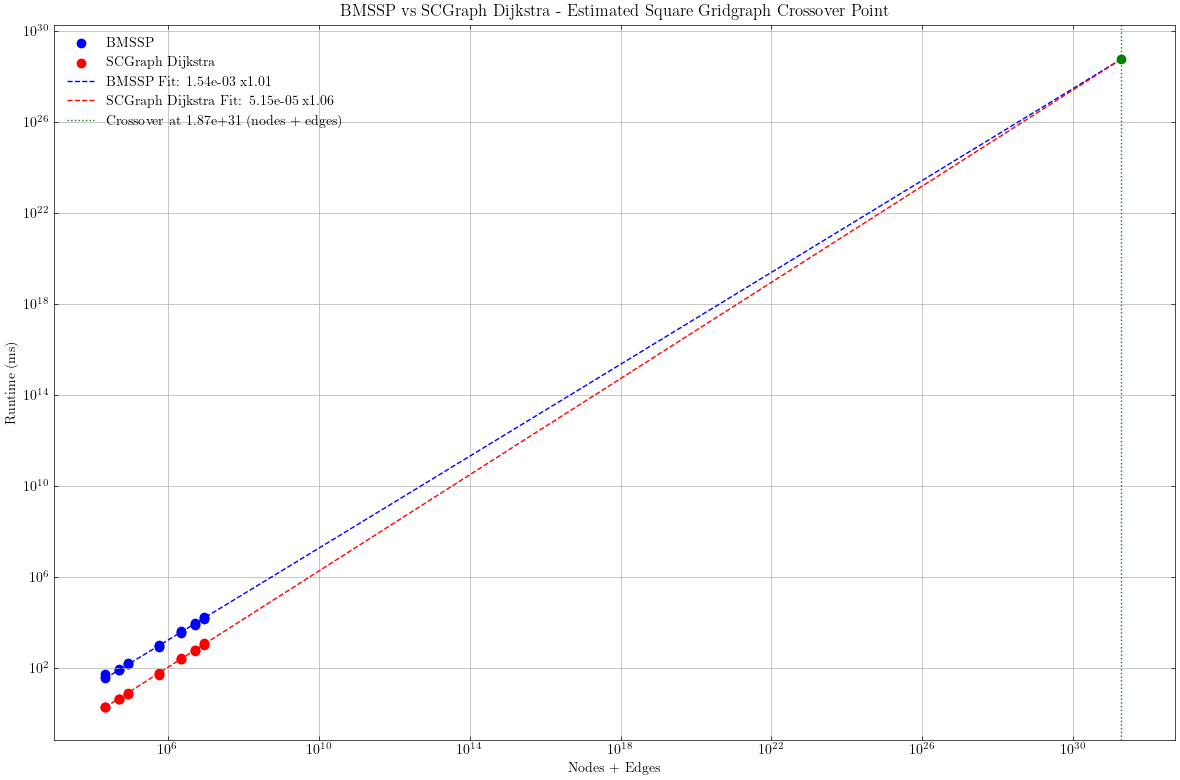

In [18]:
# x_vals = [i['graph_nodes']+i['graph_edges'] for i in gridscale_data]
# y_bmssp = [i["bmssp_solve_time_ms"] for i in gridscale_data]
# y_purepy = [i["sc_dijkstra_time_ms"] for i in gridscale_data]
x_vals = [i['graph_nodes']+i['graph_edges'] for i in square_grid_data]
y_bmssp = [i["bmssp_solve_time_ms"] for i in square_grid_data]
y_purepy = [i["sc_dijkstra_time_ms"] for i in square_grid_data]

a1, b1 = fit_curve(x_vals, y_bmssp)
a2, b2 = fit_curve(x_vals, y_purepy)
x_crossover = find_crossover(a1, b1, a2, b2)

plot_with_crossover(x_vals, y_bmssp, y_purepy, a1, b1, a2, b2, x_crossover,
    algo_1_name="BMSSP",
    algo_2_name="SCGraph Dijkstra",
    title="BMSSP vs SCGraph Dijkstra - Estimated Square Gridgraph Crossover Point",
    scale="log",
)

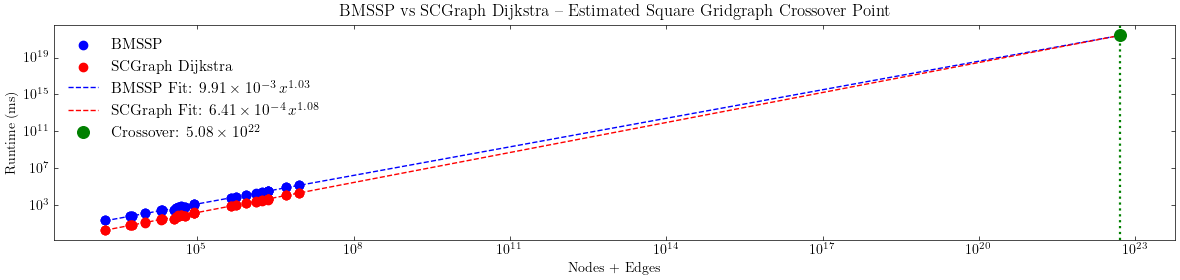

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------
# 1. Helpers: power law, fit, crossover, scientific notation
# --------------------------------------------------------------------
def power_law(x, a, b):
    x = np.asarray(x, dtype=float)
    return a * np.power(x, b)

def fit_curve(x_vals, y_vals):
    x = np.asarray(x_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)

    mask = (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]

    logx = np.log(x)
    logy = np.log(y)

    b, loga = np.polyfit(logx, logy, 1)
    a = np.exp(loga)
    return a, b

def find_crossover(a1, b1, a2, b2):
    if a1 <= 0 or a2 <= 0: return None
    if np.isclose(b1, b2): return None
    x = (a2 / a1) ** (1.0 / (b1 - b2))
    if x <= 0 or not np.isfinite(x):
        return None
    return x

def sci_notation(a):
    a = float(a)
    if a == 0:
        return 0.0, 0
    exp = int(np.floor(np.log10(abs(a))))
    mant = a / (10.0**exp)
    return mant, exp

# --------------------------------------------------------------------
# 2. Data extraction
# --------------------------------------------------------------------
x_vals = np.array([row["graph_nodes"] + row["graph_edges"] for row in gridscale_data])
y_bmssp = np.array([row["bmssp_constant_degree_solve_time_ms"] for row in gridscale_data])
y_scgraph = np.array([row["pure_python_sc_dijkstra_constant_degree_time_ms"] for row in gridscale_data])

# --------------------------------------------------------------------
# 3. Fit curves and crossover
# --------------------------------------------------------------------
a1, b1 = fit_curve(x_vals, y_bmssp)
a2, b2 = fit_curve(x_vals, y_scgraph)

x_crossover = find_crossover(a1, b1, a2, b2)

x_min = x_vals.min()
x_max_data = x_vals.max()
x_max = max(x_max_data, (x_crossover * 1.2) if x_crossover else x_max_data * 1.2)

x_fit = np.linspace(x_min, x_max, 400)
y1_fit = power_law(x_fit, a1, b1)
y2_fit = power_law(x_fit, a2, b2)

# --------------------------------------------------------------------
# 4. Build LaTeX labels
# --------------------------------------------------------------------
m1, e1 = sci_notation(a1)
m2, e2 = sci_notation(a2)

bmssp_label = rf"$\text{{BMSSP Fit: }} {m1:.2f}\times 10^{{{e1}}}\, x^{{{b1:.2f}}}$"
scgraph_label = rf"$\text{{SCGraph Fit: }} {m2:.2f}\times 10^{{{e2}}}\, x^{{{b2:.2f}}}$"

# Crossover legend label
if x_crossover is not None:
    mc, ec = sci_notation(x_crossover)
    crossover_label = rf"$\text{{Crossover: }} {mc:.2f}\times 10^{{{ec}}}$"
else:
    crossover_label = None

# --------------------------------------------------------------------
# 5. Plot
# --------------------------------------------------------------------
plt.figure(figsize=(12, 3))

# Raw points
plt.scatter(x_vals, y_bmssp, label="BMSSP", color="blue")
plt.scatter(x_vals, y_scgraph, label="SCGraph Dijkstra", color="red")

# Fit lines
plt.plot(x_fit, y1_fit, label=bmssp_label, color="blue", linestyle="--")
plt.plot(x_fit, y2_fit, label=scgraph_label, color="red", linestyle="--")

# Crossover indicator line + ghost legend handle
if x_crossover is not None:
    y_cross = power_law(x_crossover, a1, b1)

    # vertical line
    plt.axvline(x_crossover, color="green", linestyle=":", linewidth=1.6)
    y_cross = power_law(x_crossover, a1, b1)
    m_x, e_x = sci_notation(x_crossover)
    plt.scatter([x_crossover], [y_cross], color="green", s=70, zorder=5, label=crossover_label)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Nodes + Edges")
plt.ylabel("Runtime (ms)")
plt.title("BMSSP vs SCGraph Dijkstra – Estimated Square Gridgraph Crossover Point")

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("square_grid_crossover.pdf")
plt.show()


/tmp/ipython-input-1901045723.py:63: RuntimeWarning: invalid value encountered in power
  reg = C * m * (np.log(D*n) ** (2/3))



===== Estimated Model Parameters =====
C = 3.649 × 10^-3
B = 9.868 × 10^-4
D = 9.622 × 10^-1
E = 6.547 × 10^-1

===== CROSSOVER (Generalized Model) =====
No crossover found in range 1e3–1e30.

BMSSP (C,D) Model Fit Statistics:
  R²      = 0.9984
  RMSE    = 1540.10 ms
  MAE     = 810.91 ms
  MAPE    = 11.79%

Dijkstra (B,E) Model Fit Statistics:
  R²      = 0.9559
  RMSE    = 1101.62 ms
  MAE     = 413.56 ms
  MAPE    = 38.74%


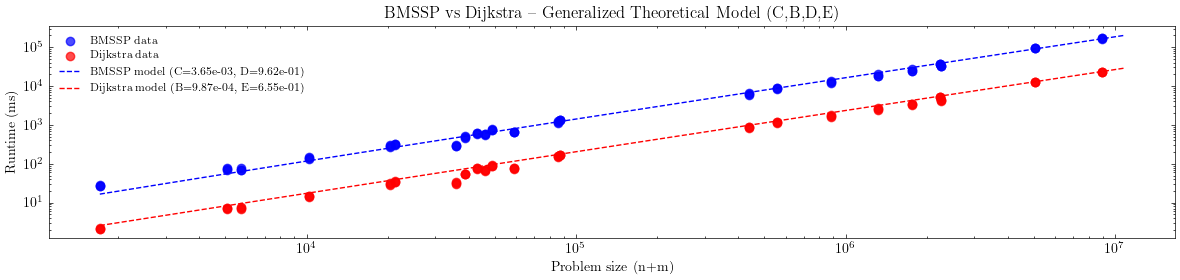

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from numpy.linalg import lstsq

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def sci_notation(a):
    if a == 0: return 0.0, 0
    exp = int(np.floor(np.log10(abs(a))))
    mant = a / (10.0**exp)
    return mant, exp

def mape(actual, pred):
    actual = np.asarray(actual, float)
    pred   = np.asarray(pred,   float)
    mask = actual > 0
    return np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100


# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
n = np.array([row["graph_nodes"] for row in gridscale_data], dtype=float)
m = np.array([row["graph_edges"] for row in gridscale_data], dtype=float)

t_bmssp = np.array([row["bmssp_constant_degree_solve_time_ms"]
                    for row in gridscale_data], dtype=float)
t_dij = np.array([row["pure_python_sc_dijkstra_constant_degree_time_ms"]
                  for row in gridscale_data], dtype=float)

mask = np.isfinite(n) & np.isfinite(m) & np.isfinite(t_bmssp) & np.isfinite(t_dij)
n, m, t_bmssp, t_dij = n[mask], m[mask], t_bmssp[mask], t_dij[mask]

alpha = np.mean(m/n)     # average m/n ratio
logn = np.log(n)


# ---------------------------------------------------------
# 2. Fit C, B for original theoretical forms
# ---------------------------------------------------------
X_b = m * (logn ** (2/3))
X_d = m + n * logn

C = np.sum(X_b * t_bmssp) / np.sum(X_b**2)
B = np.sum(X_d * t_dij)    / np.sum(X_d**2)

pred_bmssp = C * X_b
pred_dij   = B * X_d


# ---------------------------------------------------------
# 3. Fit scale factors D and E
# ---------------------------------------------------------
# BMSSP: fit log(D) such that m(log(Dn))^(2/3) best matches t_bmssp
def fit_D(C, n, m, t):
    # Search over scale values in log-space
    D_vals = np.logspace(-5, 5, 300)
    best_D = 1
    best_err = np.inf
    for D in D_vals:
        reg = C * m * (np.log(D*n) ** (2/3))
        err = np.mean((t - reg)**2)
        if np.isfinite(err) and err < best_err:
            best_err = err
            best_D = D
    return best_D

# Dijkstra: fit E such that m + n*log(E n) makes best fit
def fit_E(B, n, m, t):
    E_vals = np.logspace(-5, 5, 300)
    best_E = 1
    best_err = np.inf
    for E in E_vals:
        reg = B * (m + n * np.log(E*n))
        err = np.mean((t - reg)**2)
        if np.isfinite(err) and err < best_err:
            best_err = err
            best_E = E
    return best_E

D = fit_D(C, n, m, t_bmssp)
E = fit_E(B, n, m, t_dij)

print("\n===== Estimated Model Parameters =====")
mC,eC = sci_notation(C)
mB,eB = sci_notation(B)
mD,eD = sci_notation(D)
mE,eE = sci_notation(E)
print(f"C = {mC:.3f} × 10^{eC}")
print(f"B = {mB:.3f} × 10^{eB}")
print(f"D = {mD:.3f} × 10^{eD}")
print(f"E = {mE:.3f} × 10^{eE}")


# ---------------------------------------------------------
# 4. Solve crossover using your requested form
# ---------------------------------------------------------
def solve_crossover_n(alpha, C, B, D, E):
    n_search = np.logspace(3, 30, 20000)

    lognL = np.log(D*n_search)
    lognR = np.log(E*n_search)

    lhs = C * alpha * (lognL ** (2/3))
    rhs = B * (alpha + lognR)

    diff = lhs - rhs
    idx = np.where(np.sign(diff[:-1]) != np.sign(diff[1:]))[0]

    if len(idx)==0:
        return None
    return n_search[idx[0]]

n_cross = solve_crossover_n(alpha, C, B, D, E)

print("\n===== CROSSOVER (Generalized Model) =====")
if n_cross is None:
    print("No crossover found in range 1e3–1e30.")
    x_cross = None
else:
    x_cross = n_cross * (1+alpha)
    mn,en = sci_notation(n_cross)
    mx,ex = sci_notation(x_cross)
    print(f"n_cross  ≈ {mn:.2f} × 10^{en}")
    print(f"x_cross ≈ {mx:.2f} × 10^{ex}")

# ---------------------------------------------------------
# 4b. Evaluate model quality with C,B,D,E
# ---------------------------------------------------------

# Compute log arguments safely (avoid negative logs)
logDn = np.log(np.maximum(D*n, 1e-12))
logEn = np.log(np.maximum(E*n, 1e-12))

bmssp_pred_final = C * m * (logDn ** (2/3))
dij_pred_final   = B * (m + n * logEn)

# Ensure predictions are finite
mask_valid_b = np.isfinite(bmssp_pred_final)
mask_valid_d = np.isfinite(dij_pred_final)

def report_stats(name, actual, pred):
    """Compute R2, RMSE, MAE, MAPE for a model."""
    # filter invalid values
    mask = np.isfinite(actual) & np.isfinite(pred) & (actual > 0)
    actual, pred = actual[mask], pred[mask]

    r2  = r2_score(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = np.mean(np.abs(actual - pred))
    mape_val = np.mean(np.abs((actual - pred) / actual)) * 100

    print(f"\n{name} Model Fit Statistics:")
    print(f"  R²      = {r2:.4f}")
    print(f"  RMSE    = {rmse:.2f} ms")
    print(f"  MAE     = {mae:.2f} ms")
    print(f"  MAPE    = {mape_val:.2f}%")

# BMSSP report
report_stats("BMSSP (C,D)", t_bmssp, bmssp_pred_final)

# Dijkstra report
report_stats("Dijkstra (B,E)", t_dij, dij_pred_final)


# ---------------------------------------------------------
# 5. Build curves and plot
# ---------------------------------------------------------
x_vals = n+m
x_min = x_vals.min()
x_max = max(x_vals.max(), (x_cross or x_vals.max()) * 1.2)

x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 400)
n_fit = x_fit / (1+alpha)
m_fit = alpha * n_fit

lognL_fit = np.log(D*n_fit)
lognR_fit = np.log(E*n_fit)

bmssp_curve = C * m_fit * (lognL_fit ** (2/3))
dij_curve   = B * (m_fit + n_fit * lognR_fit)


# ---------------------------------------------------------
# 6. Plot
# ---------------------------------------------------------
plt.figure(figsize=(12,3))

plt.scatter(x_vals, t_bmssp, color="blue", alpha=0.7, label="BMSSP data")
plt.scatter(x_vals, t_dij,   color="red",  alpha=0.7, label="Dijkstra data")

plt.plot(x_fit, bmssp_curve, color="blue", linestyle="--",
         label=f"BMSSP model (C={C:.2e}, D={D:.2e})")
plt.plot(x_fit, dij_curve,   color="red",  linestyle="--",
         label=f"Dijkstra model (B={B:.2e}, E={E:.2e})")

if x_cross is not None:
    t_cross = C*(alpha*n_cross)*(np.log(D*n_cross)**(2/3))
    plt.axvline(x_cross, color="green", linestyle=":", linewidth=1.6)
    plt.scatter([x_cross], [t_cross], color="green", s=70, label=f"Crossover x≈{mx:.2f}e{ex}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Problem size (n+m)")
plt.ylabel("Runtime (ms)")
plt.title("BMSSP vs Dijkstra – Generalized Theoretical Model (C,B,D,E)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
